# Time-resolved uncertainty analysis using `dL`

This notebook focuses on the measured quantity **penetration length** `L`. The aim is to assign each tr dataset to a specified biscuit and investigate whether a ML model or the washburn equation is better suited to predicting penetration Length and then use the uncertainty column `dL` to provide a statistical backbone to this hypothesis.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1 load data

In [5]:
dunk = pd.read_csv('dunking-data.csv')
tr1 = pd.read_csv('tr-1.csv')
tr2 = pd.read_csv('tr-2.csv')
tr3 = pd.read_csv('tr-3.csv')

# Experimental conditions for all time-resolved datasets
gamma = 6.78e-2
phi = 1.45
eta = 9.93e-4

# Store the three unknown trajectories in one dictionary.
# This keeps labels attached to the data throughout the notebook.
tr_data = {
    'tr1': tr1,
    'tr2': tr2,
    'tr3': tr3
}

for label, df in tr_data.items():
    df[['gamma', 'phi', 'eta']] = [gamma, phi, eta]
    df['L2'] = df['L']**2
    df['dL2'] = 2 * df['L'] * df['dL']  # propagated uncertainty for plotting L^2

    df['dL2'] = 2 * df['L'] * df['dL']
    df['dataset'] = label

# initial visualisation

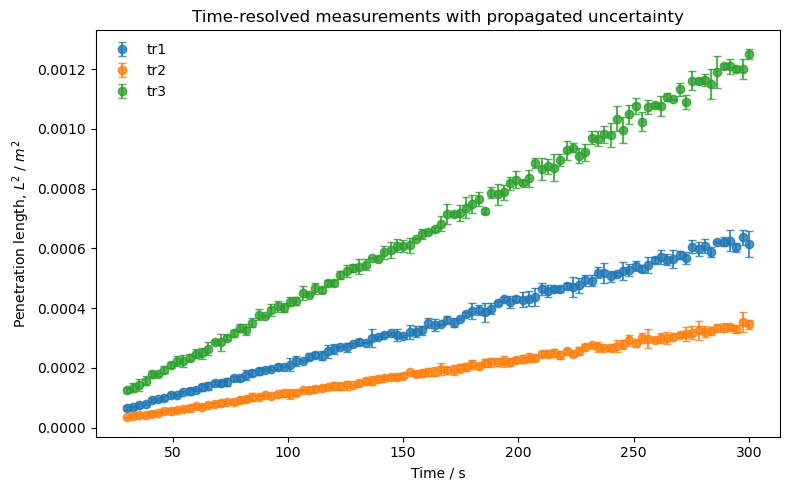

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, df in tr_data.items():
    ax.errorbar(
        df['t'],
        df['L2'],
        yerr=df['dL2'],
        fmt='o',
        label=label,
        capsize=3,
        alpha=0.8
    )

ax.set_xlabel('Time / s')
ax.set_ylabel('Penetration length, $L^2$ / $m^2$')
ax.set_title('Time-resolved measurements with propagated uncertainty')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## determine which tr datasets fits which biscuit

In [7]:
# Mean pore radii taken from the microscopy analysis workflow
representative_radii = {
    'Hobnob': 4.975634e-07,
    'Rich Tea': 3.133841e-07,
    'Digestive': 7.922873e-07
}

# Consistent colours used throughout the report
biscuit_colours = {
    'Digestive': 'red',
    'Hobnob': 'orange',
    'Rich Tea': 'blue'
}


def washburn_L(t, r):
    """Washburn prediction for penetration length L."""
    return np.sqrt((gamma * r * t * np.cos(phi)) / (2 * eta))

In [8]:
for tr_label, df in tr_data.items():

    for biscuit, r in representative_radii.items():

        # predicted L using that biscuit's representative radius
        pred_L = washburn_L(df['t'].values, r)

        # save prediction
        df[f'{biscuit}_washburn_L'] = pred_L
        df[f'{biscuit}_washburn_L2'] = pred_L**2

        # residual in measured quantity L
        df[f'{biscuit}_residual_L'] = df['L'] - pred_L

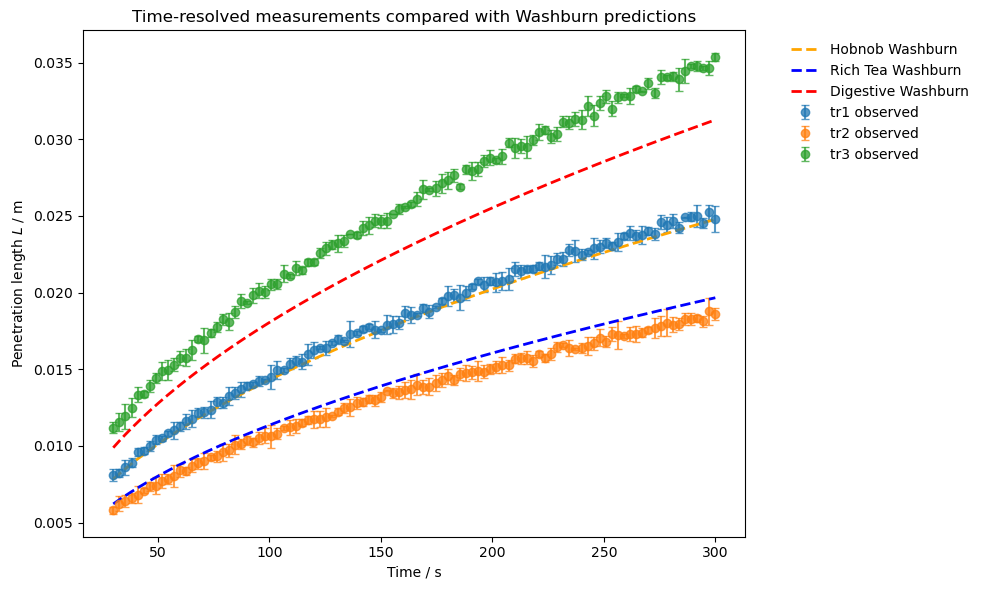

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# Observed tr1-tr3 measurements
for tr_label, df in tr_data.items():
    ax.errorbar(
        df['t'],
        df['L'],
        yerr=df['dL'],
        fmt='o',
        capsize=3,
        alpha=0.75,
        label=f'{tr_label} observed'
    )

# Smooth shared time axis for the three Washburn hypotheses
t_smooth = np.linspace(
    min(df['t'].min() for df in tr_data.values()),
    max(df['t'].max() for df in tr_data.values()),
    200
)

for biscuit, r in representative_radii.items():
    ax.plot(
        t_smooth,
        washburn_L(t_smooth, r),
        linestyle='--',
        linewidth=2,
        color=biscuit_colours[biscuit],
        label=f'{biscuit} Washburn'
    )

ax.set_xlabel('Time / s')
ax.set_ylabel('Penetration length $L$ / m')
ax.set_title('Time-resolved measurements compared with Washburn predictions')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

From inspection, each time-resolved trajectory appears closest to a different biscuit-specific Washburn curve. However, the provided uncertainty values $dL$ allow this assignment to be tested quantitatively using a reduced chi-squared statistic,

$$chi^2_
u = \frac{1}{N-1}\Sigma(\frac{L_{obs}-L_{pred}}{dL})^2.$$

This is calculated using $L$, rather than $L^2$, because $L$ is the directly measured quantity and $dL$ is the experimental uncertainty supplied with the data.

In [12]:
def chi_sq(L_obs,L_pred,dL):
    chi2 = np.sum(((L_obs-L_pred)/dL)**2)
    dof = len(L_obs) - 1
    red_chi2 = chi2 / dof
    return red_chi2

In [ ]:
chi2_results = []

for tr_label, df in tr_data.items():

    for biscuit, r in representative_radii.items():

        L_pred = washburn_L(df['t'], r)

        # chi-squared using provided uncertainty dL
        red_chi2 = chi_sq(df['L'],L_pred,df['dL']) 


        chi2_results.append({
            'Dataset': tr_label,
            'Biscuit hypothesis': biscuit,
            'Reduced Chi2': red_chi2
        })

chi2_results = pd.DataFrame(chi2_results)

chi2_summary = chi2_results.pivot(
    index='Dataset',
    columns='Biscuit hypothesis',
    values='Reduced Chi2'
)

chi2_summary

In [ ]:
# Select the biscuit hypothesis with the lowest reduced chi-squared for each dataset
best_assignments = (
    chi2_results
    .sort_values('Reduced Chi2')
    .groupby('Dataset')
    .first()['Biscuit hypothesis']
    .to_dict()
)

best_assignments

{'tr1': 'Hobnob', 'tr2': 'Rich Tea', 'tr3': 'Digestive'}

In [ ]:
# Add only the best-assignment Washburn prediction to each dataframe.
# This avoids carrying unnecessary columns into the final analysis.
for tr_label, df in tr_data.items():
    best_biscuit = best_assignments[tr_label]
    r = representative_radii[best_biscuit]

    df['assigned_biscuit'] = best_biscuit
    df['washburn_L'] = washburn_L(df['t'], r)
    df['washburn_L2'] = df['washburn_L']**2
    df['washburn_residual_L'] = df['L'] - df['washburn_L']
    df['residual_over_dL'] = np.abs(df['washburn_residual_L']) / df['dL']

The reduced $chi^2$ values provide a quantitative assignment of each unknown trajectory. This does not replace the visual comparison; it strengthens it by weighting each residual by the experimental uncertainty. Large values also indicate where the Washburn model deviates by more than measurement error alone, showing genuine limitations of the ideal capillary model.

# Fitting ML models

In [ ]:
# Build analysis information from the chi-squared assignments rather than hard-coding labels
tr_info = {}

for tr_label, df in tr_data.items():
    biscuit = best_assignments[tr_label]
    tr_info[biscuit] = {
        'dataset': tr_label,
        'df': df,
        'colour': biscuit_colours[biscuit]
    }


In [ ]:
def train_biscuit_L2_model(dunk_df, biscuit_name):
    """Train a simple biscuit-specific linear model for L^2."""
    subset = dunk_df[dunk_df['biscuit'] == biscuit_name].copy()

    X = subset[['gamma', 'phi', 'eta', 't']]
    y = subset['L']**2

    model = LinearRegression()
    model.fit(X, y)

    return model


linear_L2_models = {
    biscuit: train_biscuit_L2_model(dunk, biscuit)
    for biscuit in representative_radii.keys()
}

# Apply the assigned biscuit-specific ML model to each time-resolved dataset
for tr_label, df in tr_data.items():
    biscuit = best_assignments[tr_label]
    model = linear_L2_models[biscuit]

    X_tr = df[['gamma', 'phi', 'eta', 't']]
    ml_L2 = model.predict(X_tr)
    ml_L2 = np.clip(ml_L2, 0, None)

    df['ml_L2'] = ml_L2
    df['ml_L'] = np.sqrt(ml_L2)
    df['ml_residual_L'] = df['L'] - df['ml_L']
    df['ml_residual_over_dL'] = np.abs(df['ml_residual_L']) / df['dL']

In [ ]:
rows = []

for biscuit, info in tr_info.items():
    df = info['df']

    rows.append({
        'Dataset': info['dataset'],
        'Assigned biscuit': biscuit,
        'Washburn RMSE L': np.sqrt(mean_squared_error(df['L'], df['washburn_L'])),
        'ML RMSE L': np.sqrt(mean_squared_error(df['L'], df['ml_L'])),
        'Washburn MAE L': mean_absolute_error(df['L'], df['washburn_L']),
        'ML MAE L': mean_absolute_error(df['L'], df['ml_L']),
        'Mean Washburn |residual|/dL': df['residual_over_dL'].mean(),
        'Mean ML |residual|/dL': df['ml_residual_over_dL'].mean(),
        'Washburn RMSE L2': np.sqrt(mean_squared_error(df['L2'], df['washburn_L2'])),
        'ML RMSE L2': np.sqrt(mean_squared_error(df['L2'], df['ml_L2'])),
        'Washburn R2 L2': r2_score(df['L2'], df['washburn_L2']),
        'ML R2 L2': r2_score(df['L2'], df['ml_L2'])
    })

tr_metrics = pd.DataFrame(rows)
tr_metrics

,Dataset,Assigned biscuit,Washburn RMSE L,ML RMSE L,Washburn MAE L,ML MAE L,Mean Washburn |residual|/dL,Mean ML |residual|/dL,Washburn RMSE L2,ML RMSE L2,Washburn R2 L2,ML R2 L2
0,tr1,Hobnob,0.000428,0.000209,0.000375,0.000169,1.435650,0.676290,0.000017,0.000008,0.989141,0.997490
1,tr2,Rich Tea,0.000828,0.001586,0.000788,0.001495,2.493998,4.753433,0.000026,0.000052,0.916714,0.666501
2,tr3,Digestive,0.002916,0.001660,0.002809,0.001612,16.362453,9.292887,0.000159,0.000091,0.760121,0.921237


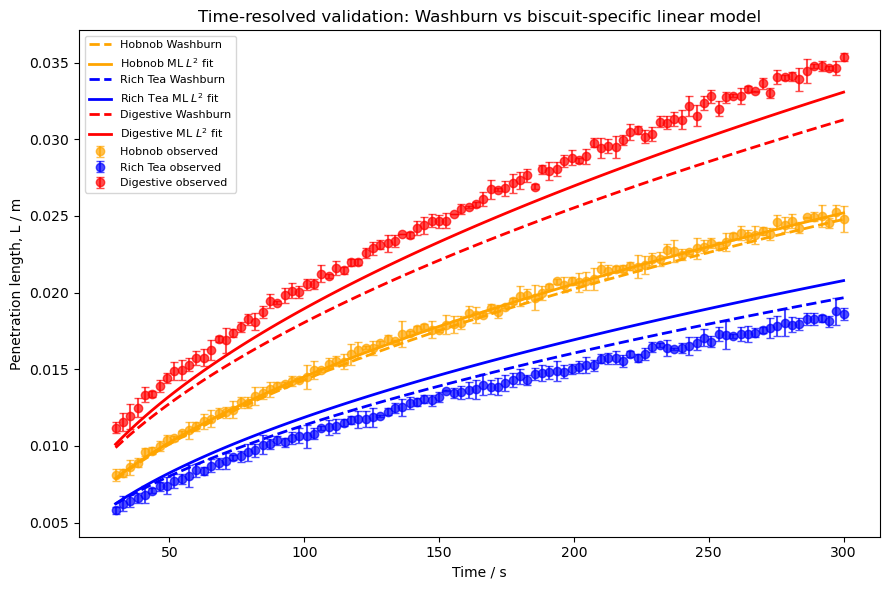

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for biscuit, info in tr_info.items():
    df = info['df'].sort_values('t')
    colour = info['colour']

    ax.errorbar(
        df['t'],
        df['L'],
        yerr=df['dL'],
        fmt='o',
        color=colour,
        alpha=0.7,
        capsize=3,
        label=f'{biscuit} observed'
    )

    ax.plot(
        df['t'],
        df['washburn_L'],
        color=colour,
        linestyle='--',
        linewidth=2,
        label=f'{biscuit} Washburn'
    )

    ax.plot(
        df['t'],
        df['ml_L'],
        color=colour,
        linestyle='-',
        linewidth=2,
        label=f'{biscuit} ML $L^2$ fit'
    )

ax.set_xlabel("Time / s")
ax.set_ylabel("Penetration length, L / m")
ax.set_title("Time-resolved validation: Washburn vs biscuit-specific linear model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

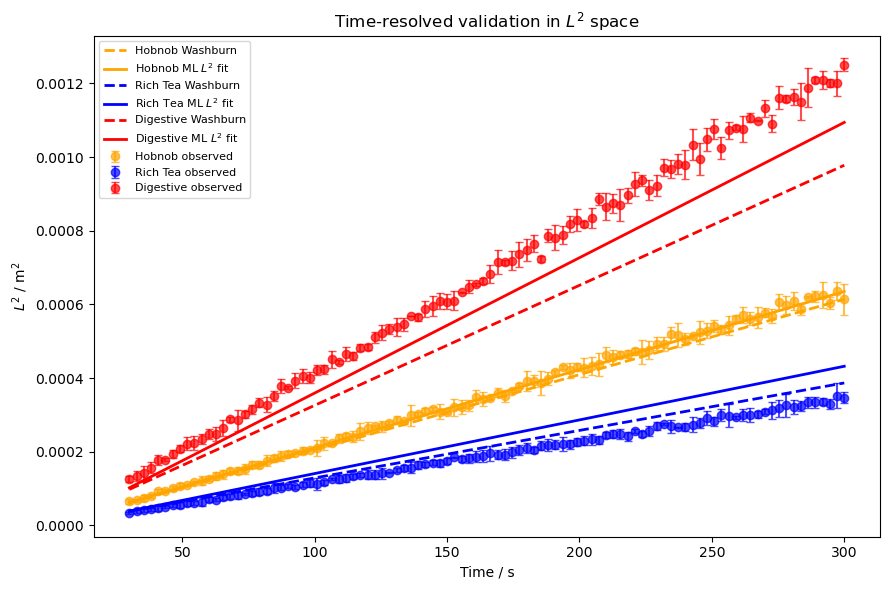

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for biscuit, info in tr_info.items():
    df = info['df'].sort_values('t')
    colour = info['colour']

    ax.errorbar(
        df['t'],
        df['L2'],
        yerr=df['dL2'],
        fmt='o',
        color=colour,
        alpha=0.7,
        capsize=3,
        label=f'{biscuit} observed'
    )

    ax.plot(
        df['t'],
        df['washburn_L2'],
        color=colour,
        linestyle='--',
        linewidth=2,
        label=f'{biscuit} Washburn'
    )

    ax.plot(
        df['t'],
        df['ml_L2'],
        color=colour,
        linestyle='-',
        linewidth=2,
        label=f'{biscuit} ML $L^2$ fit'
    )

ax.set_xlabel("Time / s")
ax.set_ylabel(r"$L^2$ / m$^2$")
ax.set_title(r"Time-resolved validation in $L^2$ space")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

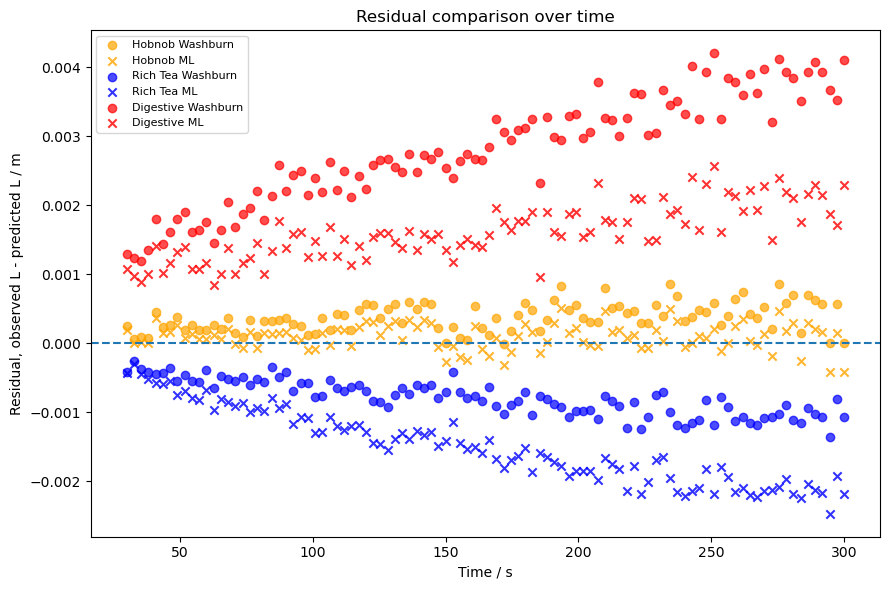

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for biscuit, info in tr_info.items():
    df = info['df'].sort_values('t')
    colour = info['colour']

    ax.scatter(
        df['t'],
        df['washburn_residual_L'],
        color=colour,
        marker='o',
        alpha=0.7,
        label=f'{biscuit} Washburn'
    )

    ax.scatter(
        df['t'],
        df['ml_residual_L'],
        color=colour,
        marker='x',
        alpha=0.8,
        label=f'{biscuit} ML'
    )

ax.axhline(0, linestyle='--')
ax.set_xlabel("Time / s")
ax.set_ylabel("Residual, observed L - predicted L / m")
ax.set_title("Residual comparison over time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Washburn error quantification 

In [ ]:
# ------------------------------------------------------------
# Residual relative to uncertainty
# ------------------------------------------------------------

uncertainty_results = []

for tr_label, df in tr_data.items():

    best_biscuit = best_assignments[tr_label]
    r = representative_radii[best_biscuit]

    # Washburn prediction
    L_pred = washburn_L(df['t'], r)

    # absolute residual
    abs_residual = np.abs(df['L'] - L_pred)

    # compare to measurement uncertainty
    residual_ratio = abs_residual / df['dL']

    df['residual_over_dL'] = residual_ratio

    uncertainty_results.append({
        'Dataset': tr_label,
        'Assigned biscuit': best_biscuit,
        'Mean |Residual| / dL': residual_ratio.mean(),
        'Median |Residual| / dL': residual_ratio.median(),
        'Max |Residual| / dL': residual_ratio.max()
    })

uncertainty_results = pd.DataFrame(uncertainty_results)
uncertainty_results

,Dataset,Assigned biscuit,Mean |Residual| / dL,Median |Residual| / dL,Max |Residual| / dL
0,tr1,Hobnob,1.435650,1.004193,15.349704
1,tr2,Rich Tea,2.493998,1.883967,16.367529
2,tr3,Digestive,16.362453,6.794164,403.507847


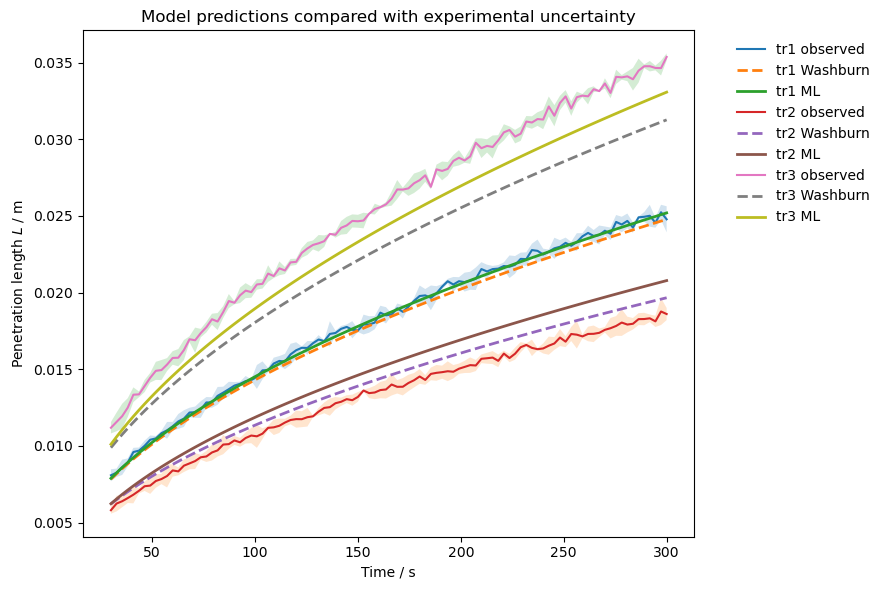

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))

for tr_label, df in tr_data.items():

    best_biscuit = best_assignments[tr_label]

    # observed
    t = df['t']
    L = df['L']
    dL = df['dL']

    # predictions
    washburn = df['washburn_L']
    ml = df['ml_L']

    # observed line
    ax.plot(
        t,
        L,
        label=f'{tr_label} observed'
    )

    # uncertainty band
    ax.fill_between(
        t,
        L - dL,
        L + dL,
        alpha=0.2
    )

    # Washburn
    ax.plot(
        t,
        washburn,
        linestyle='--',
        linewidth=2,
        label=f'{tr_label} Washburn'
    )

    # ML
    ax.plot(
        t,
        ml,
        linewidth=2,
        label=f'{tr_label} ML'
    )

ax.set_xlabel('Time / s')
ax.set_ylabel('Penetration length $L$ / m')
ax.set_title('Model predictions compared with experimental uncertainty')

ax.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

In [17]:
tr_data

{'tr1':              t         L        dL   gamma   phi       eta        L2  \
 0    30.000000  0.008087  0.000392  0.0678  1.45  0.000993  0.000065   
 1    32.727273  0.008253  0.000270  0.0678  1.45  0.000993  0.000068   
 2    35.454545  0.008607  0.000501  0.0678  1.45  0.000993  0.000074   
 3    38.181818  0.008920  0.000267  0.0678  1.45  0.000993  0.000080   
 4    40.909091  0.009604  0.000274  0.0678  1.45  0.000993  0.000092   
 ..         ...       ...       ...     ...   ...       ...       ...   
 95  289.090909  0.024948  0.000307  0.0678  1.45  0.000993  0.000622   
 96  291.818182  0.025015  0.000711  0.0678  1.45  0.000993  0.000626   
 97  294.545455  0.024558  0.000322  0.0678  1.45  0.000993  0.000603   
 98  297.272727  0.025243  0.000489  0.0678  1.45  0.000993  0.000637   
 99  300.000000  0.024784  0.000851  0.0678  1.45  0.000993  0.000614   
 
          dL2 dataset  Hobnob_washburn_L  Hobnob_washburn_L2  \
 0   0.000006     tr1           0.007836           

In [ ]:
chi2_results = []

for tr_label, df in tr_data.items():

    for biscuit, r in representative_radii.items():

        L_pred = washburn_L(df['t'], r)

        # chi-squared using provided uncertainty dL
        red_chi2 = chi_sq(df['L'],L_pred,df['dL']) 


        chi2_results.append({
            'Dataset': tr_label,
            'Biscuit hypothesis': biscuit,
            'Reduced Chi2': red_chi2
        })

chi2_results = pd.DataFrame(chi2_results)

chi2_summary = chi2_results.pivot(
    columns='Biscuit',
    values='Reduced Chi2'
)

chi2_summary

Biscuit hypothesis,Digestive,Hobnob,Rich Tea
Dataset,,,
tr1,573.393653,5.388135,510.515385
tr2,1571.451024,374.680225,11.985093
tr3,2495.809936,17425.846147,38686.327979
